In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import scienceplots
import os 
import re
import glob
from matplotlib import colormaps as cm
import glob
plt.style.use(['science','notebook','grid'])
%matplotlib inline

In [27]:
w_ref_south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')
w_ref_north = np.load('/user/animesh.sah/w_theta_results/treecorr_north_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')


In [23]:
files_north = glob.glob('/user/animesh.sah/DESI_PECVEL/shape_z_north/w_theta_results/*_jackknife*')
files_south = glob.glob('/user/animesh.sah/DESI_PECVEL/shape_z_south/w_theta_results/*_jackknife*')
order1 = ['shape_z','R_lt_18','GR_gt_068','slope1','slope2']
len_north_order1  = [994605,201738,521449,355132,264892] 
len_south_order1  = [ 1949050,   504665,679898,909127,718246]
area_north = 5155.73 #sq deg
area_south = 12179.53
def extract_cut(f):
    base = os.path.basename(f)
    return base.split('w_False_')[-1].replace('.npy','')

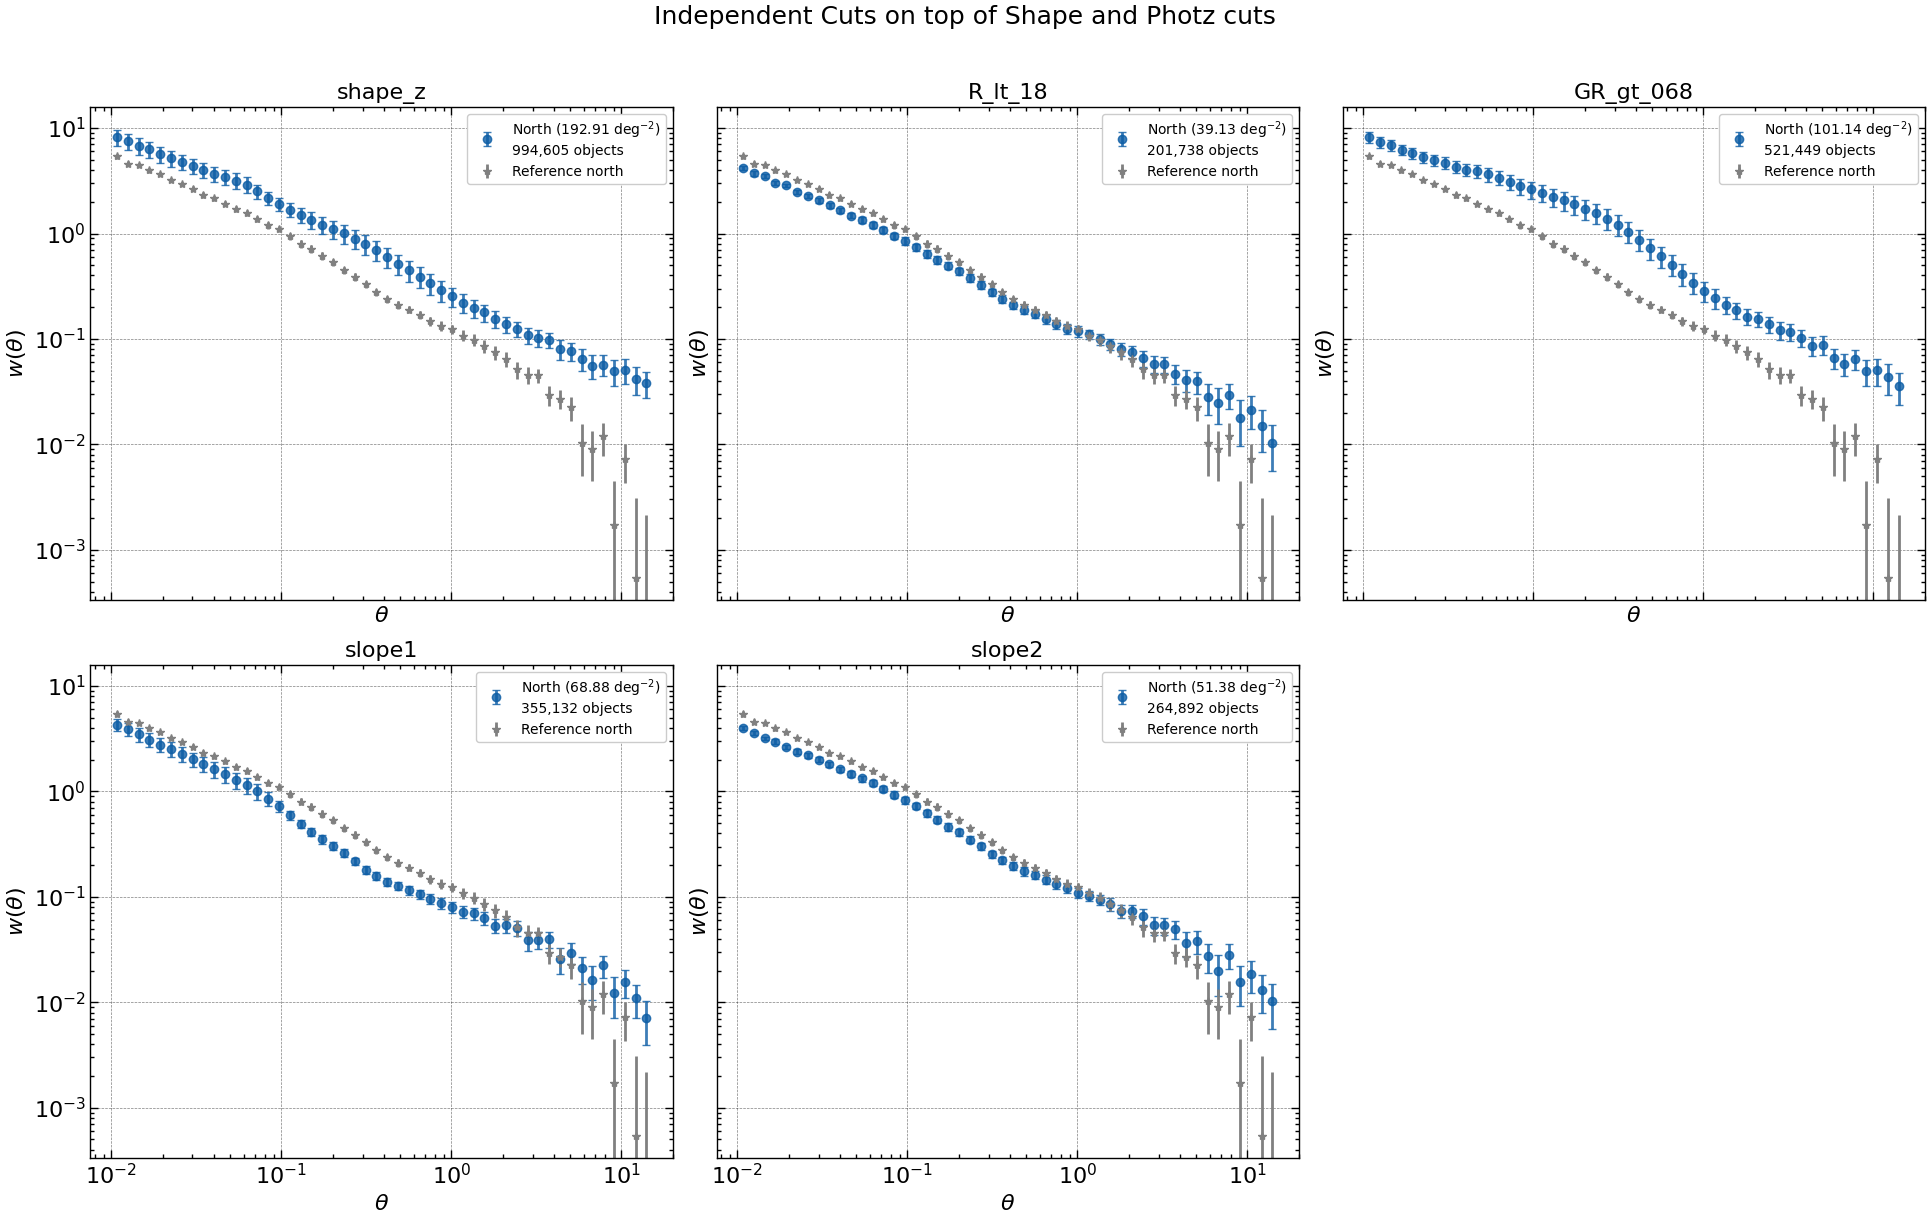

In [97]:
# Build quick lookup tables by cut name
north_by_cut = {extract_cut(f): f for f in files_north}
south_by_cut = {extract_cut(f): f for f in files_south}



n_cuts = len(order1)
n_cols = 3
n_rows = int(np.ceil(n_cuts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6.0 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, cut in enumerate(order1):
    ax = axes[i]

    # North curve
    if cut in north_by_cut:
        theta_n, w_n, sigma_n = np.load(north_by_cut[cut])
        dens_n = len_north_order1[order1.index(cut)] / area_north
        idx = order1.index(cut)
        n_obj = len_north_order1[idx]

        ax.errorbar(
            theta_n, w_n, yerr=sigma_n,
            ls='None', marker='o', capsize=3, alpha=0.8,
            label=f"North ({dens_n:.2f} deg$^{{-2}}$)\n{n_obj:,} objects"
        )
        ax.errorbar(w_ref_north[0], w_ref_north[1], yerr=w_ref_north[2],
                 ls='None', marker='*', color='gray', label='Reference north')

    # South curve
    if cut in south_by_cut:
        theta_s, w_s, sigma_s = np.load(south_by_cut[cut])
        dens_s = len_south_order1[order1.index(cut)] / area_south
        # ax.errorbar(
        #     theta_s, w_s, yerr=sigma_s, ls='None', marker='s', capsize=3,
        #     alpha=0.8, label=f'South ({dens_s:.2f} $deg^2$)'
        # )
        # ax.errorbar(w_ref_south[0], w_ref_south[1], yerr=w_ref_south[2],
        #          ls='None', marker='^', color='black', label='Reference south',alpha =0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(cut)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$w(\theta)$')
    ax.legend(fontsize=10)

# Hide empty axes (if any)
for j in range(n_cuts, len(axes)):
    axes[j].axis('off')

fig.suptitle('Independent Cuts on top of Shape and Photz cuts', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()

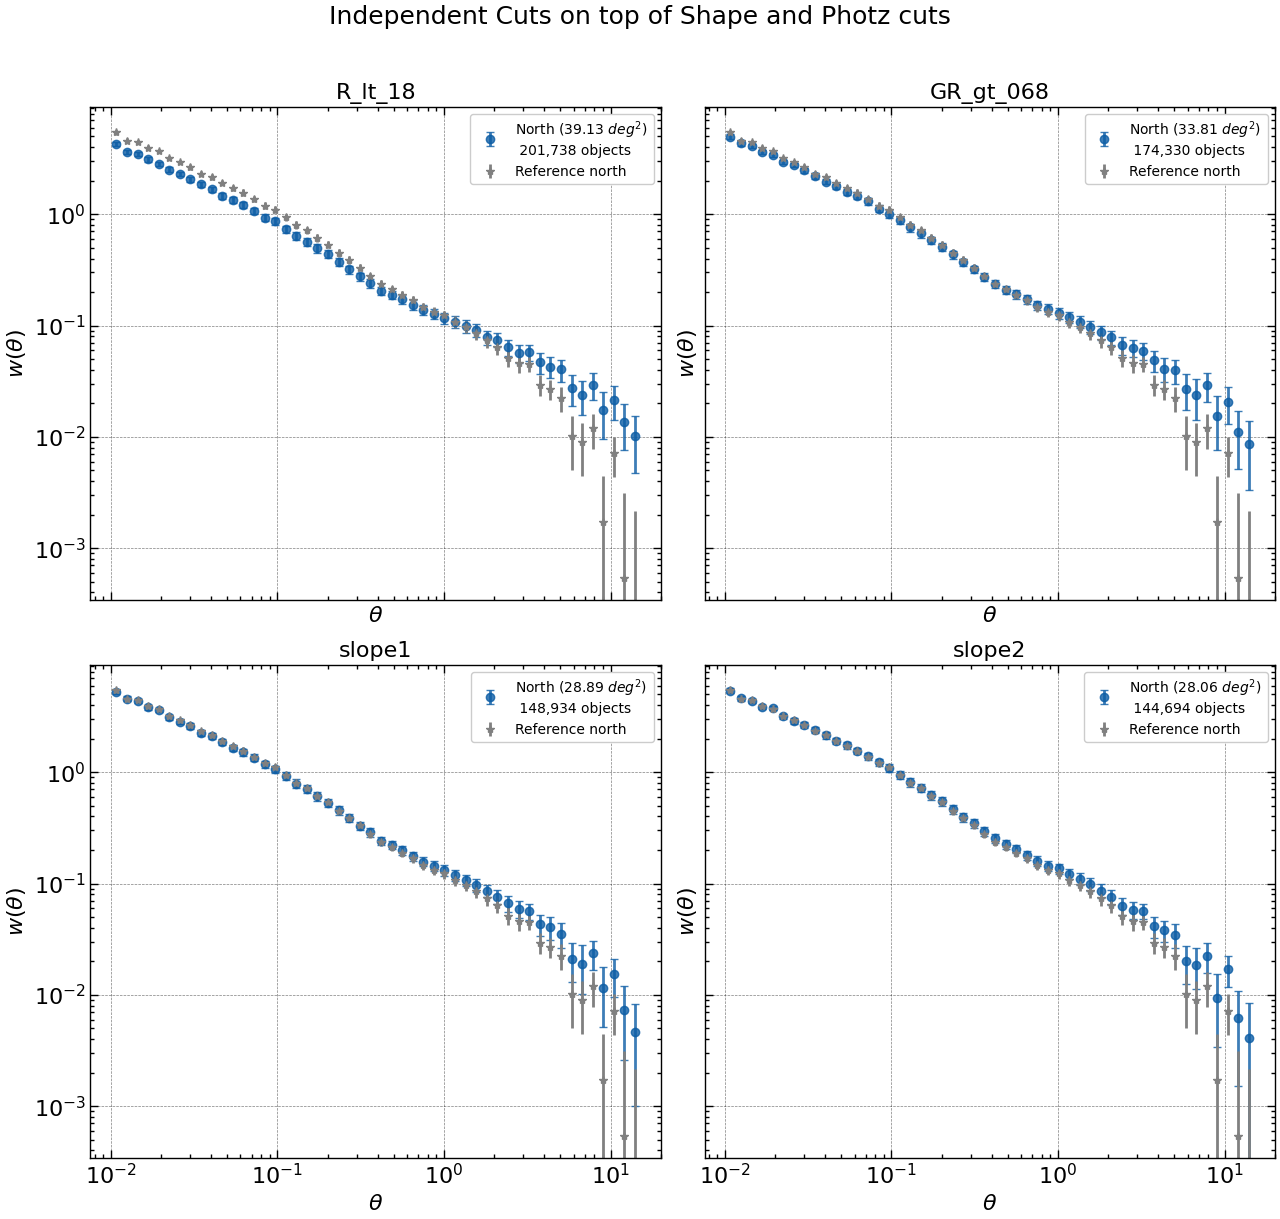

In [99]:
# Build quick lookup tables by cut name

combination1_north = '/user/animesh.sah/DESI_PECVEL/north_combination1/w_theta_results'
combination1_south = '/user/animesh.sah/DESI_PECVEL/south_combination_1/w_theta_results'
combination1 = ['R_lt_18','GR_gt_068','slope1','slope2']
#combination1 = ['slope1','slope2','GR_gt_068','R_lt_18']
files_combination1_north = glob.glob(os.path.join(combination1_north, '*_jackknife*'))
files_combination1_south = glob.glob(os.path.join(combination1_south, '*_jackknife*'))

north_by_cut_comb1 = {extract_cut(f): f for f in files_combination1_north}
south_by_cut_comb1 = {extract_cut(f): f for f in files_combination1_south}
len_north_combination1  = np.array([201738, 174330, 148934, 144694])

n_cuts = len(combination1)
n_cols = 2
n_rows = int(np.ceil(n_cuts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6.0 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, cut in enumerate(combination1):
    ax = axes[i]

    # North curve
    if cut in north_by_cut_comb1:
        theta_n, w_n, sigma_n = np.load(north_by_cut_comb1[cut])
        dens_n = len_north_combination1[combination1.index(cut)] / area_north
        n_obj = len_north_combination1[combination1.index(cut)]
        ax.errorbar(
            theta_n, w_n, yerr=sigma_n, ls='None', marker='o', capsize=3,
            alpha=0.8, label=f'North ({dens_n:.2f} $deg^2$) \n {n_obj:,} objects '
        )
        ax.errorbar(w_ref_north[0], w_ref_north[1], yerr=w_ref_north[2],
                 ls='None', marker='*', color='gray', label='Reference north')

    # South curve
    if cut in south_by_cut_comb1:
        theta_s, w_s, sigma_s = np.load(south_by_cut_comb1[cut])
        #dens_s = len_south_order1[order1.index(cut)] / area_south
        # ax.errorbar(
        #     theta_s, w_s, yerr=sigma_s, ls='None', marker='s', capsize=3,
        #     alpha=0.8, label=f'South ({dens_s:.2f} $deg^2$)'
        # )
        # ax.errorbar(w_ref_south[0], w_ref_south[1], yerr=w_ref_south[2],
        #          ls='None', marker='^', color='black', label='Reference south',alpha =0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(cut)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$w(\theta)$')
    ax.legend(fontsize=10)

# Hide empty axes (if any)
for j in range(n_cuts, len(axes)):
    axes[j].axis('off')

fig.suptitle('Independent Cuts on top of Shape and Photz cuts', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()

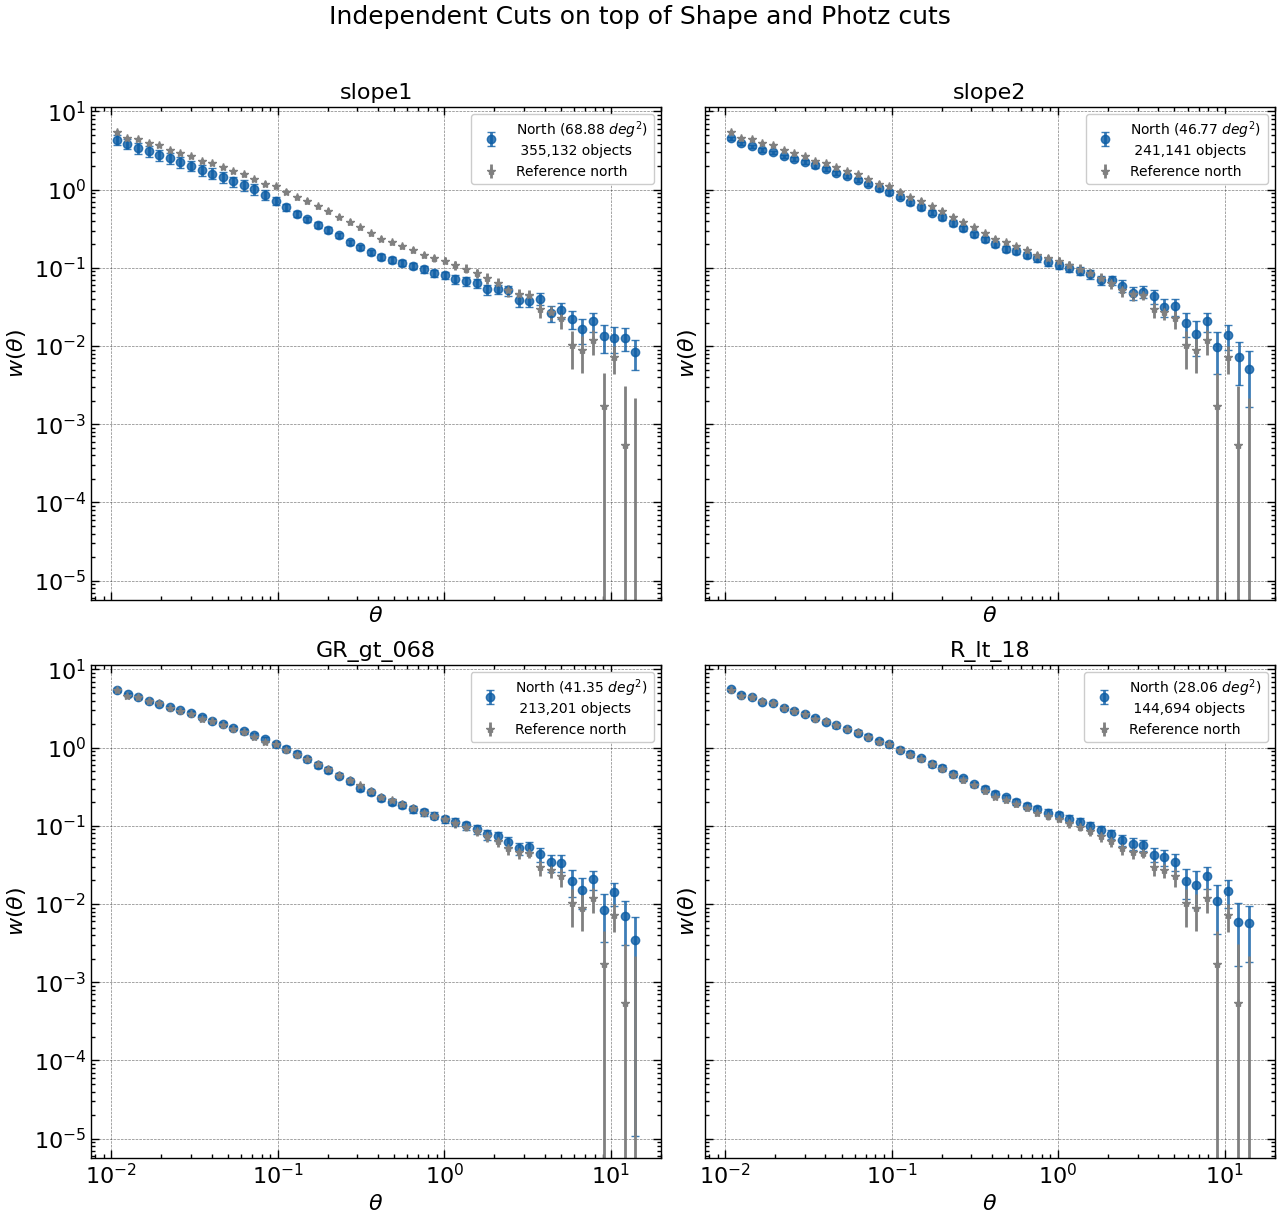

In [100]:
# Build quick lookup tables by cut name

combination2_north = '/user/animesh.sah/DESI_PECVEL/north_combination_2/w_theta_results'
combination2_south = '/user/animesh.sah/DESI_PECVEL/south_combination_2/w_theta_results'
#combination2 = ['R_lt_18','GR_gt_068','slope1','slope2']
combination2 = ['slope1','slope2','GR_gt_068','R_lt_18']
files_combination2_north = glob.glob(os.path.join(combination2_north, '*_jackknife*'))
files_combination2_south = glob.glob(os.path.join(combination2_south, '*_jackknife*'))

north_by_cut_comb2 = {extract_cut(f): f for f in files_combination2_north}
south_by_cut_comb2 = {extract_cut(f): f for f in files_combination2_south}
len_north_combination2  = np.array([355132, 241141, 213201, 144694])

n_cuts = len(combination2)
n_cols = 2
n_rows = int(np.ceil(n_cuts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6.0 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, cut in enumerate(combination2):
    ax = axes[i]

    # North curve
    if cut in north_by_cut_comb2:
        theta_n, w_n, sigma_n = np.load(north_by_cut_comb2[cut])
        dens_n = len_north_combination2[combination2.index(cut)] / area_north
        n_obj = len_north_combination2[combination2.index(cut)]
        ax.errorbar(
            theta_n, w_n, yerr=sigma_n, ls='None', marker='o', capsize=3,
            alpha=0.8, label=f'North ({dens_n:.2f} $deg^2$) \n {n_obj:,} objects  '
        )
        ax.errorbar(w_ref_north[0], w_ref_north[1], yerr=w_ref_north[2],
                 ls='None', marker='*', color='gray', label='Reference north')

    # South curve
    if cut in south_by_cut_comb2:
        theta_s, w_s, sigma_s = np.load(south_by_cut_comb2[cut])
        #dens_s = len_south_order1[order1.index(cut)] / area_south
        # ax.errorbar(
        #     theta_s, w_s, yerr=sigma_s, ls='None', marker='s', capsize=3,
        #     alpha=0.8, label=f'South ({dens_s:.2f} $deg^2$)'
        # )
        # ax.errorbar(w_ref_south[0], w_ref_south[1], yerr=w_ref_south[2],
        #          ls='None', marker='^', color='black', label='Reference south',alpha =0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(cut)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$w(\theta)$')
    ax.legend(fontsize=10)

# Hide empty axes (if any)
for j in range(n_cuts, len(axes)):
    axes[j].axis('off')

fig.suptitle('Independent Cuts on top of Shape and Photz cuts', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()

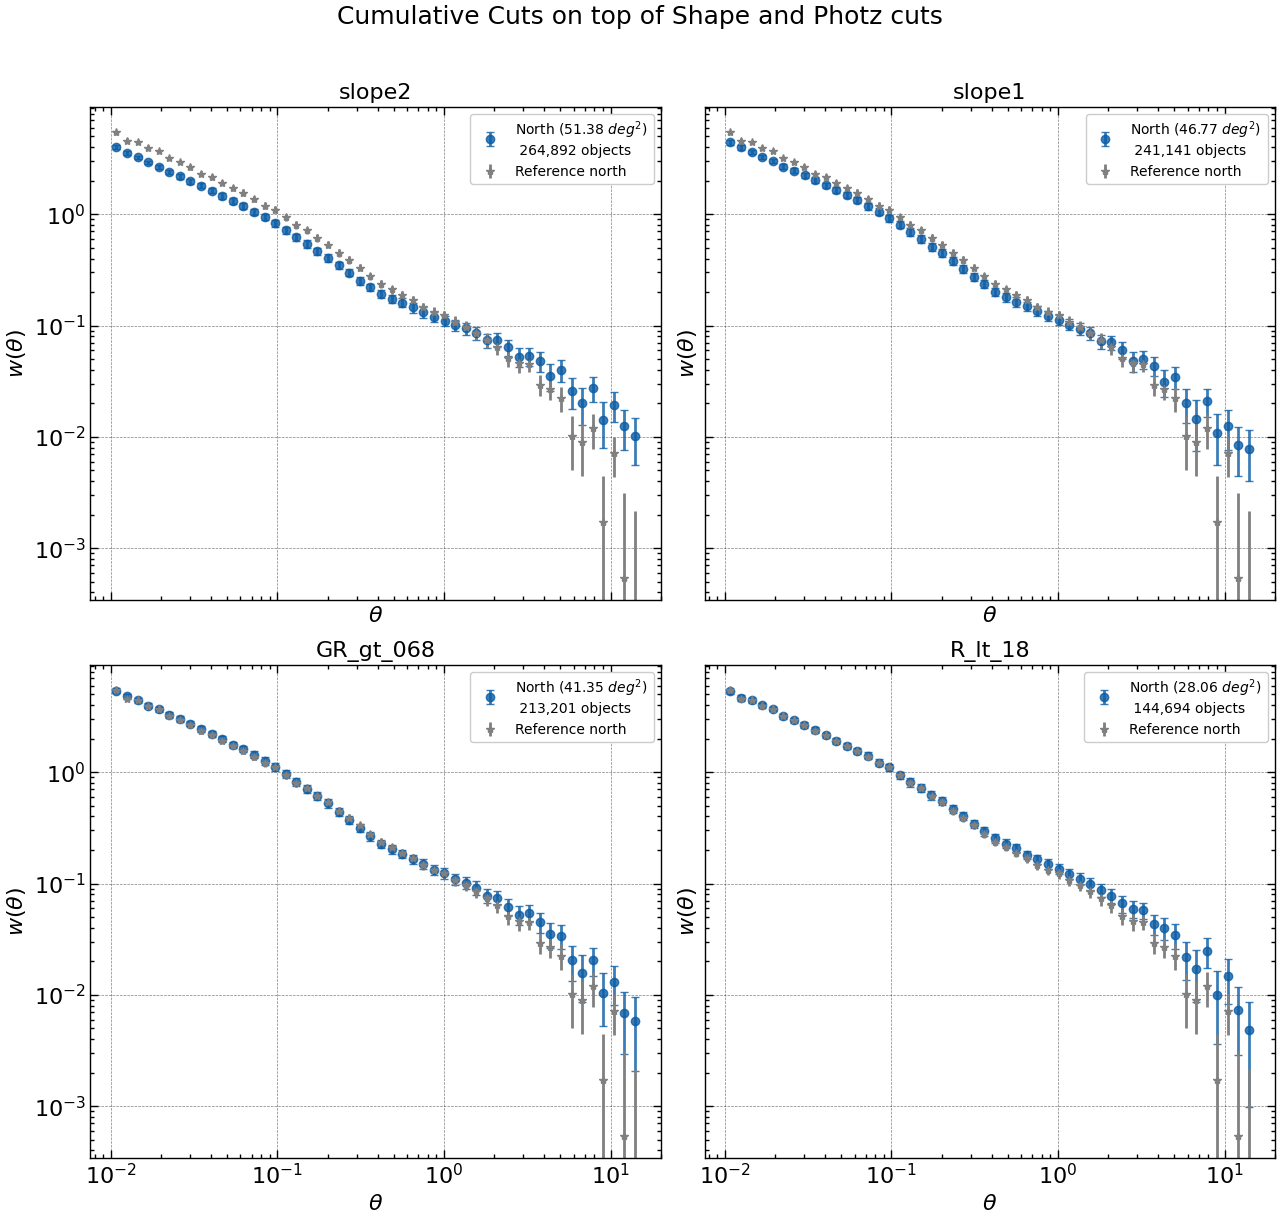

In [101]:
# Build quick lookup tables by cut name

combination3_north = '/user/animesh.sah/DESI_PECVEL/north_combination_3/w_theta_results'
combination3_south = '/user/animesh.sah/DESI_PECVEL/south_combination_3/w_theta_results'
#combination2 = ['R_lt_18','GR_gt_068','slope1','slope2']
combination3 = ['slope2','slope1','GR_gt_068','R_lt_18']
files_combination3_north = glob.glob(os.path.join(combination3_north, '*_jackknife*'))
files_combination3_south = glob.glob(os.path.join(combination3_south, '*_jackknife*'))

north_by_cut_comb3 = {extract_cut(f): f for f in files_combination3_north}
south_by_cut_comb3 = {extract_cut(f): f for f in files_combination3_south}
len_north_combination3  = np.array([264892, 241141, 213201, 144694])

n_cuts = len(combination3)
n_cols = 2
n_rows = int(np.ceil(n_cuts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6.0 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, cut in enumerate(combination3):
    ax = axes[i]

    # North curve
    if cut in north_by_cut_comb3:
        theta_n, w_n, sigma_n = np.load(north_by_cut_comb3[cut])
        dens_n = len_north_combination3[combination3.index(cut)] / area_north
        n_obj = len_north_combination3[combination3.index(cut)]
        ax.errorbar(
            theta_n, w_n, yerr=sigma_n, ls='None', marker='o', capsize=3,
            alpha=0.8, label=f'North ({dens_n:.2f} $deg^2$) \n {n_obj:,} objects  '
        )
        ax.errorbar(w_ref_north[0], w_ref_north[1], yerr=w_ref_north[2],
                 ls='None', marker='*', color='gray', label='Reference north')

    # South curve
    if cut in south_by_cut_comb3:
        theta_s, w_s, sigma_s = np.load(south_by_cut_comb3[cut])
        #dens_s = len_south_order1[order1.index(cut)] / area_south
        # ax.errorbar(
        #     theta_s, w_s, yerr=sigma_s, ls='None', marker='s', capsize=3,
        #     alpha=0.8, label=f'South ({dens_s:.2f} $deg^2$)'
        # )
        # ax.errorbar(w_ref_south[0], w_ref_south[1], yerr=w_ref_south[2],
        #          ls='None', marker='^', color='black', label='Reference south',alpha =0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(cut)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$w(\theta)$')
    ax.legend(fontsize=10)

# Hide empty axes (if any)
for j in range(n_cuts, len(axes)):
    axes[j].axis('off')

fig.suptitle('Cumulative Cuts on top of Shape and Photz cuts', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()

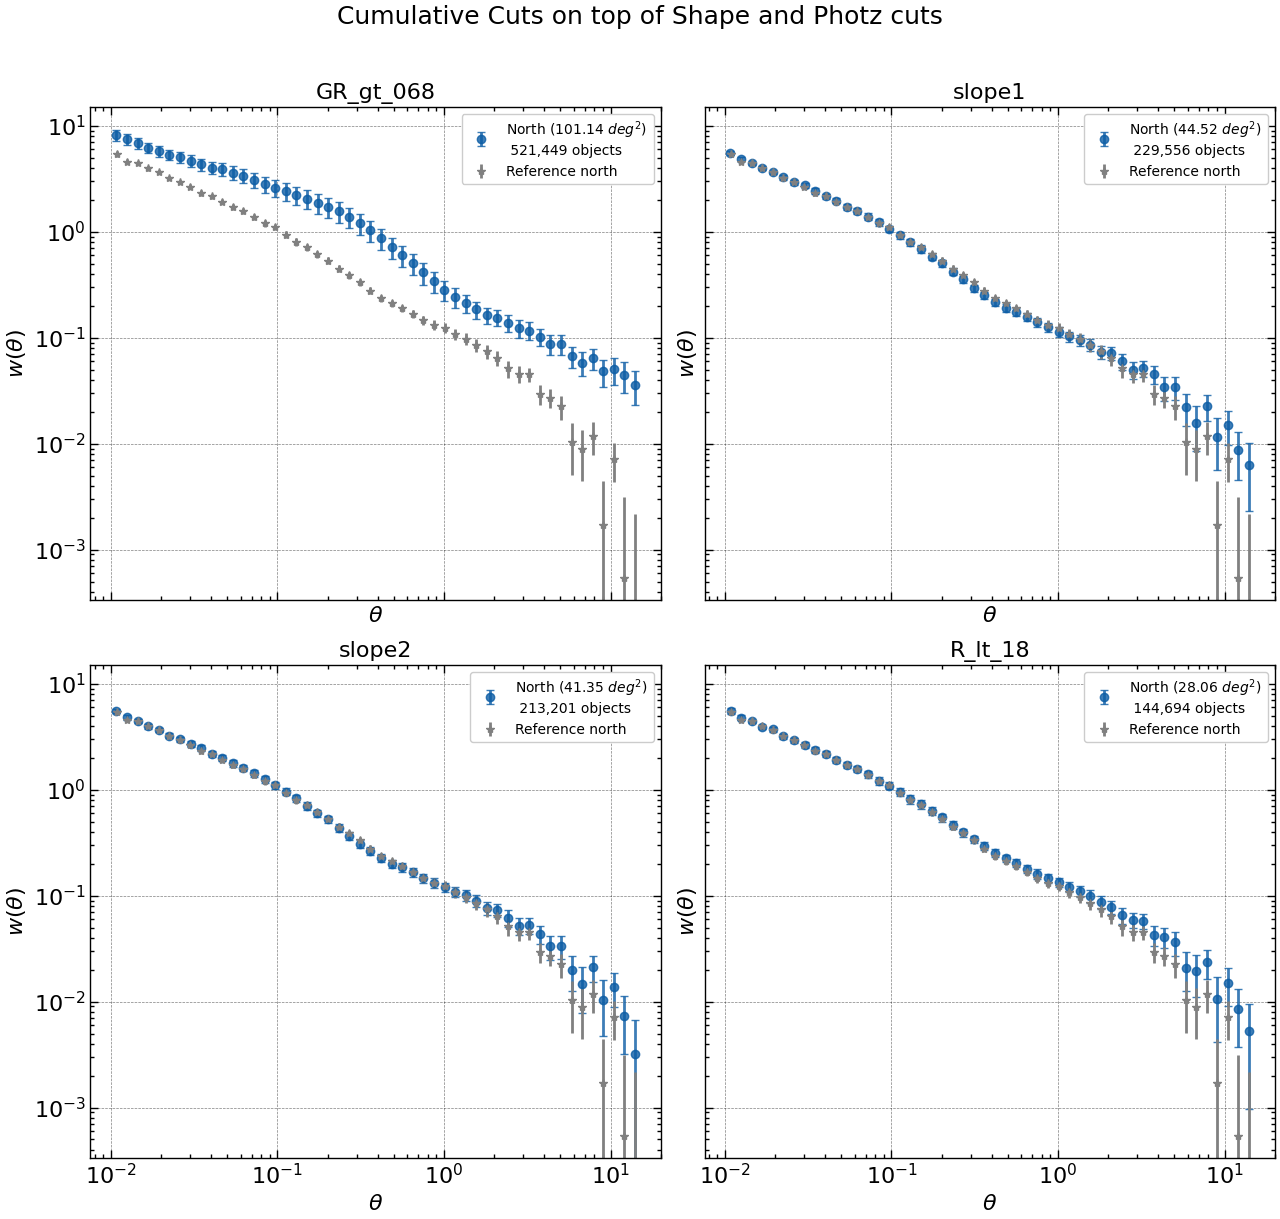

In [103]:
# Build quick lookup tables by cut name

combination4_north = '/user/animesh.sah/DESI_PECVEL/north_combination_4/w_theta_results'
combination4_south = '/user/animesh.sah/DESI_PECVEL/south_combination_4/w_theta_results'
#combination2 = ['R_lt_18','GR_gt_068','slope1','slope2']
combination4 = ['GR_gt_068','slope1','slope2','R_lt_18']
files_combination4_north = glob.glob(os.path.join(combination4_north, '*_jackknife*'))
files_combination4_south = glob.glob(os.path.join(combination4_south, '*_jackknife*'))

north_by_cut_comb4 = {extract_cut(f): f for f in files_combination4_north}
south_by_cut_comb4 = {extract_cut(f): f for f in files_combination4_south}
len_north_combination4  = np.array([521449, 229556, 213201, 144694,])

n_cuts = len(combination3)
n_cols = 2
n_rows = int(np.ceil(n_cuts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6.0 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, cut in enumerate(combination4):
    ax = axes[i]

    # North curve
    if cut in north_by_cut_comb4:
        theta_n, w_n, sigma_n = np.load(north_by_cut_comb4[cut])
        dens_n = len_north_combination4[combination4.index(cut)] / area_north
        n_obj = len_north_combination4[combination4.index(cut)]
        ax.errorbar(
            theta_n, w_n, yerr=sigma_n, ls='None', marker='o', capsize=3,
            alpha=0.8, label=f'North ({dens_n:.2f} $deg^2$) \n {n_obj:,} objects  '
        )
        ax.errorbar(w_ref_north[0], w_ref_north[1], yerr=w_ref_north[2],
                 ls='None', marker='*', color='gray', label='Reference north')

    # South curve
    if cut in south_by_cut_comb4:
        theta_s, w_s, sigma_s = np.load(south_by_cut_comb4[cut])
        #dens_s = len_south_order1[order1.index(cut)] / area_south
        # ax.errorbar(
        #     theta_s, w_s, yerr=sigma_s, ls='None', marker='s', capsize=3,
        #     alpha=0.8, label=f'South ({dens_s:.2f} $deg^2$)'
        # )
        # ax.errorbar(w_ref_south[0], w_ref_south[1], yerr=w_ref_south[2],
        #          ls='None', marker='^', color='black', label='Reference south',alpha =0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(cut)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$w(\theta)$')
    ax.legend(fontsize=10)

# Hide empty axes (if any)
for j in range(n_cuts, len(axes)):
    axes[j].axis('off')

fig.suptitle('Cumulative Cuts on top of Shape and Photz cuts', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()

In [48]:
# import os

# base_dir = "/user/animesh.sah/DESI_PECVEL/north_combination_2"  # parent directory

# mapping = {
#     "18": "R_lt_18",
#     "068": "GR_gt_068",
#     "slope1": "slope1",
#     "slope2": "slope2"
# }

# for root, dirs, files in os.walk(base_dir):
#     for f in files:
#         if f.endswith(".npy"):
#             old_path = os.path.join(root, f)

#             name = f.replace(".npy", "")
#             last_part = name.split("_")[-1]

#             if last_part in mapping:
#                 new_last = mapping[last_part]
#                 new_name = "_".join(name.split("_")[:-1] + [new_last]) + ".npy"
#                 new_path = os.path.join(root, new_name)

#                 print(f"{old_path} -> {new_path}")
#                 os.rename(old_path, new_path)